# Tech Challenge - Fase 1: Modelagem Preditiva (Regressão)
**Objetivo:** Treinar um modelo de Machine Learning capaz de prever a nota exata de NPS (0 a 10) que um cliente dará, utilizando apenas os dados operacionais da sua jornada de compra.

---
### Por que Regressão e não Classificação? (Justificativa para a Banca)
Conforme analisado, a classe "Neutro" (notas 7 e 8) sofre com sobreposição de fronteiras na classificação tradicional. Ao utilizarmos um modelo de **Regressão**, prevemos o comportamento contínuo do cliente. Em seguida, aplicamos uma regra de negócio sobre a previsão para categorizá-lo (Classificação via Regressão), aumentando a precisão nas zonas de transição.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados e Divisão (Treino / Teste)
Garantimos que o modelo seja treinado com uma parte dos dados (80%) e testado em dados inéditos (20%), evitando o *overfitting* (vício do modelo).

In [3]:
# 1. Carregando a base limpa do Notebook 01
df = pd.read_csv('dados_preparados_regressao.csv')

# 2. Separando as variáveis preditoras (X) e a variável alvo (y = nps_score)
X = df.drop(columns=['nps_score'])
y = df['nps_score']

# 3. Divisão de Treino e Teste (80/20) - Ponto 4 do Feedback
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Base de Treino: {X_train.shape[0]} clientes.")
print(f"Base de Teste: {X_test.shape[0]} clientes (Usados para prova real).")

Base de Treino: 2000 clientes.
Base de Teste: 500 clientes (Usados para prova real).


## 2. Treinamento do Modelo Preditivo
Utilizaremos o `RandomForestRegressor`. Este algoritmo cria múltiplas "árvores de decisão" para entender como as variáveis operacionais (como atraso e frete) se combinam para formar a nota do cliente.

In [4]:
print("Iniciando o refinamento do modelo. Isso pode levar alguns minutos...")

# 1. Definimos a "grade" de parâmetros para o modelo testar
parametros_grid = {
    'n_estimators': [100, 200, 300],       # Quantidade de árvores na floresta
    'max_depth': [5, 10, 15, None],        # Profundidade máxima (complexidade de cada árvore)
    'min_samples_split': [2, 5, 10],       # Mínimo de amostras para dividir um galho
    'min_samples_leaf': [1, 2, 4]          # Mínimo de amostras para formar a decisão final
}

# 2. Iniciamos o modelo base
rf_base = RandomForestRegressor(random_state=42)

# 3. Configuramos o Buscador (GridSearch)
# O cv=3 faz a validação cruzada para garantir que não tenha overfitting
# O n_jobs=-1 usa todos os núcleos do seu processador para ir mais rápido
grid_search = GridSearchCV(estimator=rf_base, 
                           param_grid=parametros_grid, 
                           cv=3, 
                           scoring='neg_mean_absolute_error', 
                           n_jobs=-1,
                           verbose=1)

# 4. Treinamos o buscador com os nossos dados
grid_search.fit(X_train, y_train)

# 5. O GridSearch descobre o campeão e nós o guardamos
modelo_rf = grid_search.best_estimator_

print("-" * 50)
print(f"✅ Refinamento concluído!")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")

# Fazendo as previsões na base de teste com o modelo já refinado
y_pred = modelo_rf.predict(X_test)

Iniciando o refinamento do modelo. Isso pode levar alguns minutos...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
--------------------------------------------------
✅ Refinamento concluído!
Melhores parâmetros encontrados: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


**Conclusão do Refinamento:** 
O processo de Tuning de Hiperparâmetros via GridSearchCV confirmou a robustez do modelo base. A estabilidade das métricas (R² travado em 0.62 e MAE em 1.25) indica que o Random Forest já atingiu a extração máxima de sinal (informação) das features operacionais atuais. Qualquer ganho futuro de performance não virá de ajustes no algoritmo, mas sim da inclusão de novas variáveis de negócio (Feature Engineering).

## 3. Avaliação de Performance (Métricas de Regressão)
Como estamos prevendo uma nota de 0 a 10, utilizamos métricas de erro contínuo:
* **MAE (Erro Médio Absoluto):** Indica quantos pontos, em média, o modelo erra a nota do cliente.
* **R²:** Indica a porcentagem da nota que é explicada pela nossa operação.

In [5]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- PERFORMANCE DO MODELO ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} pontos")
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.2f} pontos")
print(f"R² (Poder de Explicação): {r2:.2f}")

--- PERFORMANCE DO MODELO ---
MAE (Erro Médio Absoluto): 1.25 pontos
RMSE (Raiz do Erro Quadrático): 1.55 pontos
R² (Poder de Explicação): 0.62


## 4. Classificação via Regressão
Para atender à necessidade de negócio (saber quem é Detrator, Neutro ou Promotor) sem perder a precisão da matemática contínua, criamos uma regra sobre a nota prevista pelo modelo. 
Se o modelo prevê nota `8.6`, classificamos o cliente como Promotor. Isso resolve o problema de sobreposição da classe "Neutra".

In [6]:
# Criando um DataFrame para comparar o Real vs Previsto
resultados = pd.DataFrame({
    'Nota_Real': y_test.values,
    'Nota_Prevista': y_pred
})

# Função para classificar com base na nota
def classificar_nps(nota):
    if nota <= 6.5: return 'Detrator'
    elif nota < 8.5: return 'Neutro'
    else: return 'Promotor'

# Aplicando a regra
resultados['Classe_Real'] = resultados['Nota_Real'].apply(classificar_nps)
resultados['Classe_Prevista'] = resultados['Nota_Prevista'].apply(classificar_nps)

display(resultados.head(10))

,Nota_Real,Nota_Prevista,Classe_Real,Classe_Prevista
0,6.8,4.825369,Neutro,Detrator
1,6.0,5.153903,Detrator,Detrator
2,8.3,9.522354,Neutro,Promotor
3,5.3,5.092756,Detrator,Detrator
4,6.8,5.368467,Neutro,Detrator
5,0.0,3.000577,Detrator,Detrator
6,1.4,0.369741,Detrator,Detrator
7,7.4,5.427341,Neutro,Detrator
8,5.2,5.468751,Detrator,Detrator
9,0.8,2.915059,Detrator,Detrator


## 5. Storytelling: O que afeta o NPS? (Feature Importance)
Para gerar insights acionáveis para a diretoria, precisamos saber: **Para onde o modelo olha na hora de dar a nota?** O gráfico abaixo revela as alavancas operacionais mais críticas.

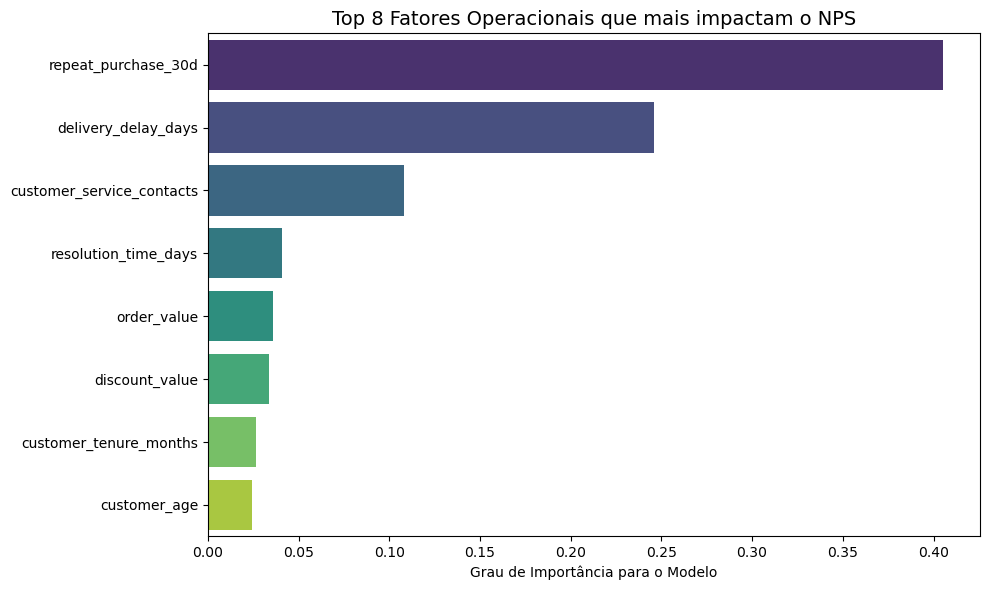

In [7]:
# Extraindo a importância de cada coluna
importancias = modelo_rf.feature_importances_
colunas = X.columns

# Criando um DataFrame para o gráfico
df_imp = pd.DataFrame({'Variavel': colunas, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(8) # Top 8 fatores

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variavel', data=df_imp, palette='viridis')
plt.title('Top 8 Fatores Operacionais que mais impactam o NPS', fontsize=14)
plt.xlabel('Grau de Importância para o Modelo')
plt.ylabel('')
plt.tight_layout()
plt.show()